In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the dataset
DATASET_PATH = "/Users/mac/AID103-kuldeepsingh8949/CropGuard-AI-Disease-Detection/plantvillage dataset/color"

In [3]:
def load_images(dataset_path, img_size=(224, 224), max_images_per_class=50):
    images = []
    labels = []
    class_names = os.listdir(dataset_path)

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_file in os.listdir(class_path):
            if count >= max_images_per_class:
                break

            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, img_size)
            img = img / 255.0

            images.append(img)
            labels.append(label)
            count += 1

    return np.array(images), np.array(labels), class_names

In [4]:
# Load images and labels
x, y, classes = load_images(DATASET_PATH)
x.shape, y.shape

((1900, 224, 224, 3), (1900,))

In [5]:
classes

['Strawberry___healthy',
 'Grape___Black_rot',
 'Potato___Early_blight',
 'Blueberry___healthy',
 'Corn_(maize)___healthy',
 'Tomato___Target_Spot',
 'Peach___healthy',
 'Potato___Late_blight',
 'Tomato___Late_blight',
 'Tomato___Tomato_mosaic_virus',
 'Pepper,_bell___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Tomato___Leaf_Mold',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Cherry_(including_sour)___Powdery_mildew',
 'Apple___Cedar_apple_rust',
 'Tomato___Bacterial_spot',
 'Grape___healthy',
 'Tomato___Early_blight',
 'Corn_(maize)___Common_rust_',
 'Grape___Esca_(Black_Measles)',
 'Raspberry___healthy',
 'Tomato___healthy',
 'Cherry_(including_sour)___healthy',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Apple___Apple_scab',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Peach___Bacterial_spot',
 'Pepper,_bell___Bacterial_spot',
 'Tomato___Septoria_leaf_spot',
 'Squash___Powdery_mildew',
 'Corn_(maize)___Cercospora_leaf_

In [6]:
# Train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
x_train.shape, x_test.shape

((1520, 224, 224, 3), (380, 224, 224, 3))

In [7]:
y_train.shape, y_test.shape

((1520,), (380,))

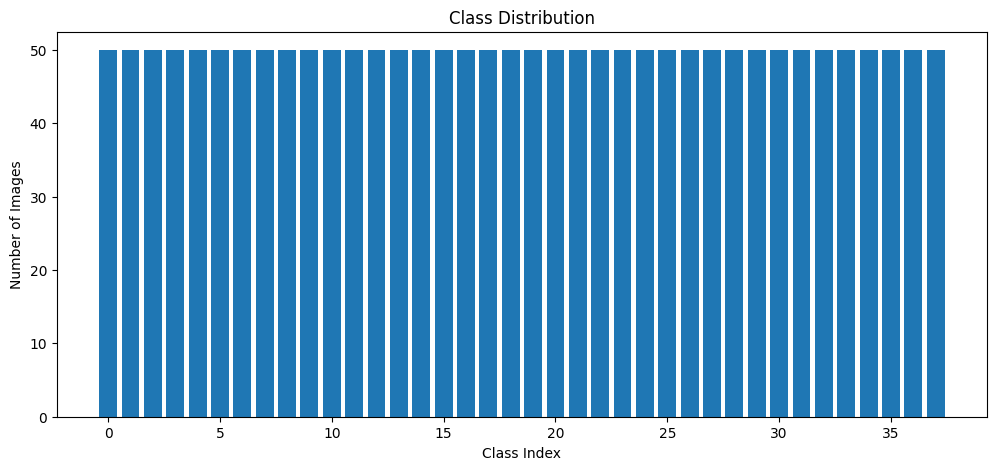

In [8]:
# class distribution visualization
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(12,5))
plt.bar(unique, counts)
plt.xlabel("Class Index")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

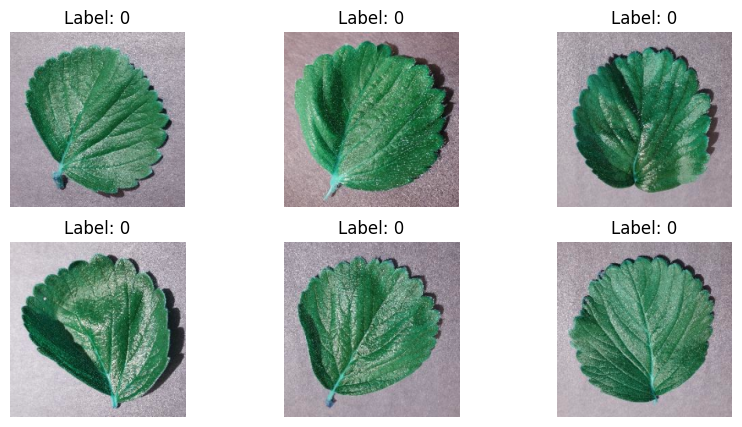

In [9]:
# visualize some sample images
plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x[i])
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.show()

In [10]:
unique_shapes = set([img.shape for img in x[:20]])
unique_shapes

{(224, 224, 3)}

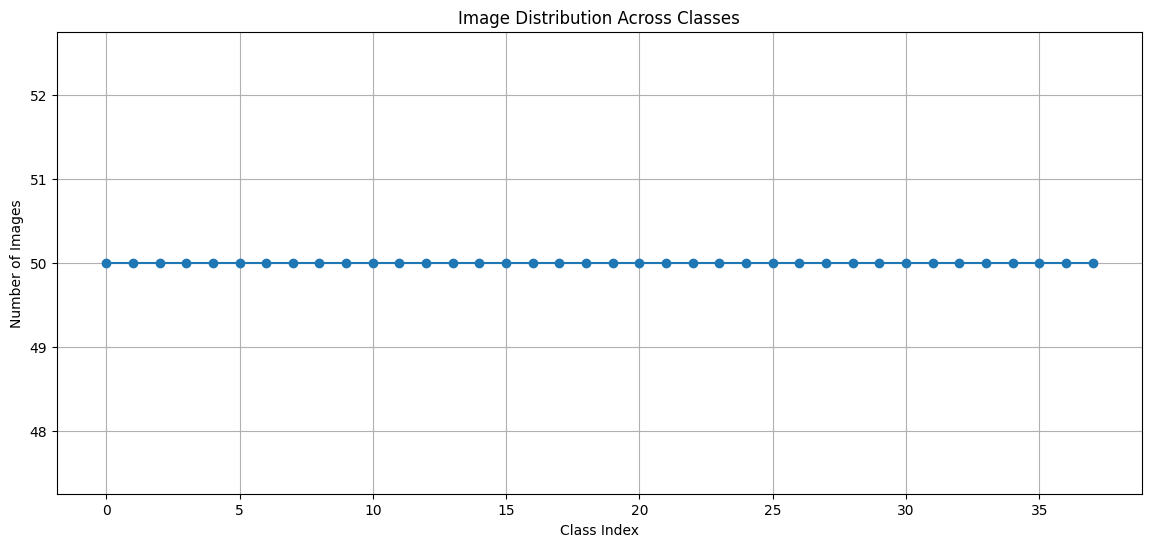

In [11]:
import pandas as pd
class_counts = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(14,6))
plt.plot(class_counts.values, marker='o')
plt.xlabel("Class Index")
plt.ylabel("Number of Images")
plt.title("Image Distribution Across Classes")
plt.grid(True)
plt.show()

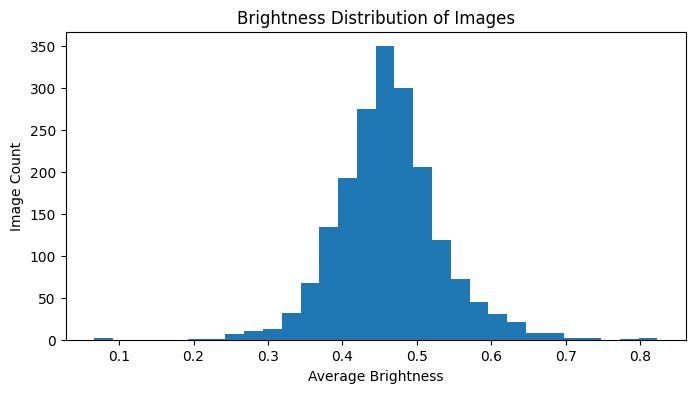

In [12]:
brightness = x.mean(axis=(1,2,3))

plt.figure(figsize=(8,4))
plt.hist(brightness, bins=30)
plt.xlabel("Average Brightness")
plt.ylabel("Image Count")
plt.title("Brightness Distribution of Images")
plt.show()

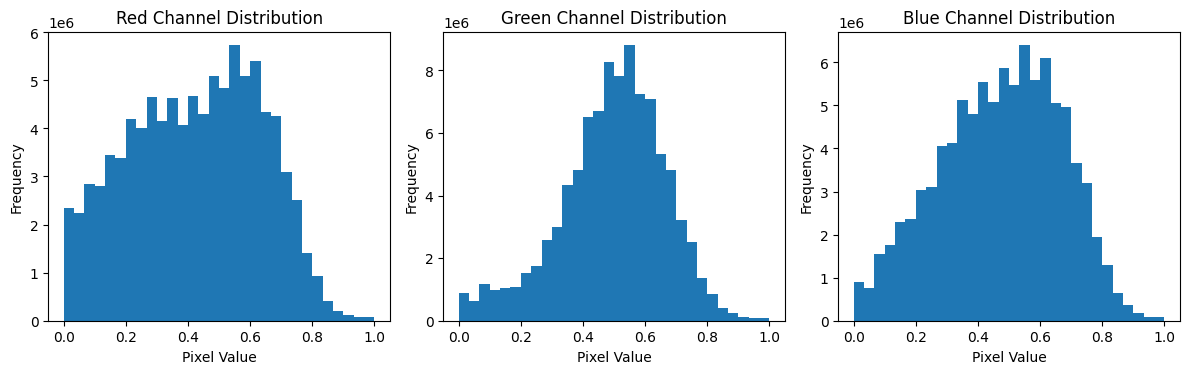

In [13]:
# RGB channel distribution and histograms
colors = ['Red', 'Green', 'Blue']

plt.figure(figsize=(12,4))
for i, color in enumerate(colors):
    plt.subplot(1,3,i+1)
    plt.hist(x[:,:,:,i].flatten(), bins=30)
    plt.title(f"{color} Channel Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
# Detect Low-Information Images (Blur Check)
def is_blurry(image, threshold=100):
    gray = cv2.cvtColor((image*255).astype("uint8"), cv2.COLOR_RGB2GRAY)
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()
    return variance < threshold

blurry_count = sum(is_blurry(img) for img in x[:200])
blurry_count

0

In [15]:
original_shapes = []

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        img = cv2.imread(os.path.join(cls_path, os.listdir(cls_path)[0]))
        original_shapes.append(img.shape[:2])

set(original_shapes)

{(256, 256)}

In [16]:
# One-hot encode labels
from tensorflow.keras.utils import to_categorical
num_classes = len(classes)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [17]:
y_train_cat.shape, y_test_cat.shape

((1520, 38), (380, 38))

In [18]:
# Build CNN Model 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
model.save("model.h5")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the CNN Model
history = model.fit(x_train, y_train_cat, validation_data=(x_test, y_test_cat), epochs=20, batch_size=16)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 54s 552ms/step - accuracy: 0.0441 - loss: 3.6871 - val_accuracy: 0.0526 - val_loss: 3.5301
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 53s 560ms/step - accuracy: 0.0993 - loss: 3.4040 - val_accuracy: 0.1289 - val_loss: 3.2560
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 52s 542ms/step - accuracy: 0.2000 - loss: 2.9718 - val_accuracy: 0.2105 - val_loss: 2.9694
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 64s 675ms/step - accuracy: 0.3421 - loss: 2.4250 - val_accuracy: 0.2684 - val_loss: 2.8630
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 59s 624ms/step - accuracy: 0.4809 - loss: 1.9018 - val_accuracy: 0.3289 - val_loss: 2.7578
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 669ms/step - accuracy: 0.5914 - loss: 1.4669 - val_accuracy: 0.3500 - val_loss: 2.6899
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 55s 576ms/step - accuracy: 0.6822 - loss: 1.1151 - val_accuracy: 0.3711 - val_loss: 2.8987
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 55s 579ms/step - accuracy: 0.7934 - loss: 0.6956 - val_accu

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
datagen.fit(x_train)

history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=16),
    validation_data=(x_test, y_test_cat),
    epochs=20,
    batch_size=16
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 57s 594ms/step - accuracy: 0.2724 - loss: 2.8830 - val_accuracy: 0.4868 - val_loss: 2.1200
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 55s 578ms/step - accuracy: 0.3829 - loss: 2.2517 - val_accuracy: 0.4421 - val_loss: 1.9597
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 54s 564ms/step - accuracy: 0.4013 - loss: 2.1357 - val_accuracy: 0.5263 - val_loss: 1.6791
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 609ms/step - accuracy: 0.4586 - loss: 1.9434 - val_accuracy: 0.5526 - val_loss: 1.5990
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 64s 676ms/step - accuracy: 0.4901 - loss: 1.7898 - val_accuracy: 0.5658 - val_loss: 1.5694
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 852ms/step - accuracy: 0.5243 - loss: 1.6679 - val_accuracy: 0.5763 - val_loss: 1.6153
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.5289 - loss: 1.6051 - val_accuracy: 0.5763 - val_loss: 1.5138
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.5454 - loss: 1.5602 - val_accuracy

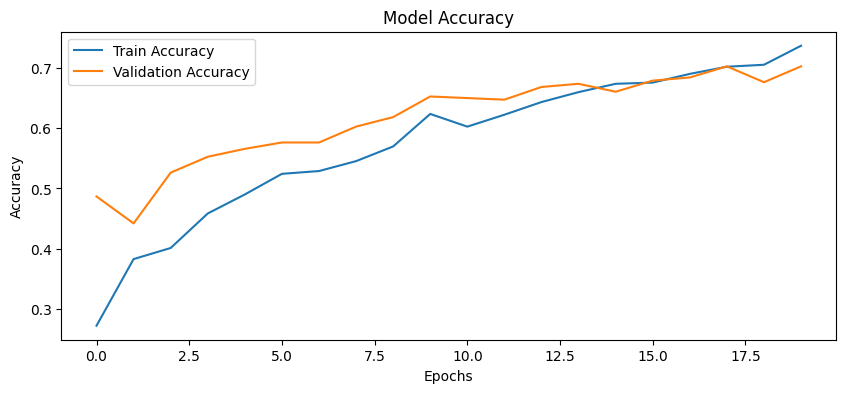

In [22]:
# Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

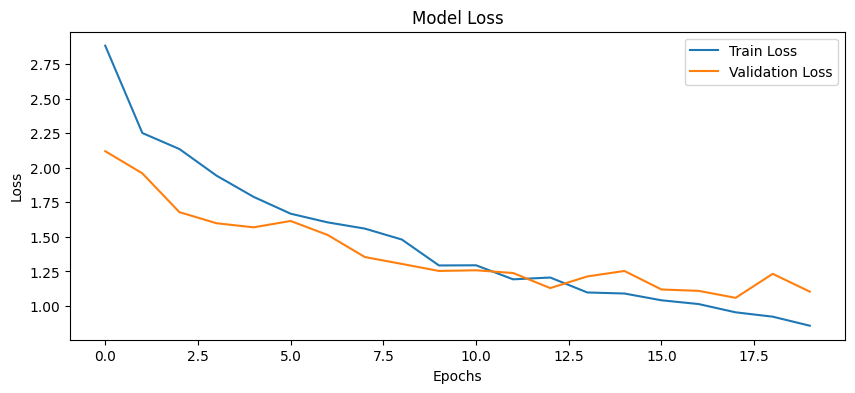

In [23]:
# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.7026 - loss: 1.1041
Test Accuracy: 0.7026315927505493


In [25]:
model.evaluate(x_test, y_test_cat)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 294ms/step - accuracy: 0.7026 - loss: 1.1041


[1.1040918827056885, 0.7026315927505493]

In [26]:
# Predict class labels
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 353ms/step


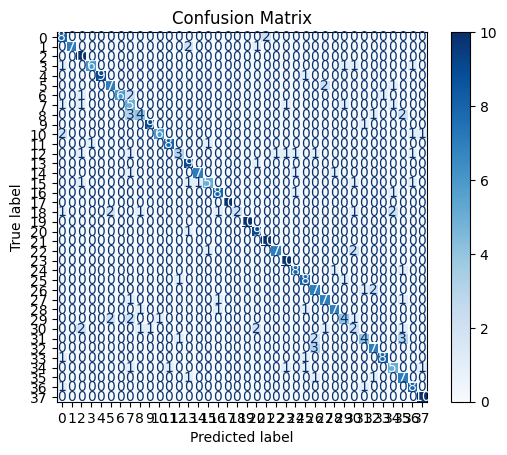

In [27]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.53      0.80      0.64        10
           1       1.00      0.70      0.82        10
           2       0.62      1.00      0.77        10
           3       0.86      0.60      0.71        10
           4       1.00      0.90      0.95        10
           5       0.64      0.70      0.67        10
           6       1.00      0.60      0.75        10
           7       0.31      0.50      0.38        10
           8       0.57      0.40      0.47        10
           9       0.90      0.90      0.90        10
          10       0.86      0.60      0.71        10
          11       0.89      0.80      0.84        10
          12       0.60      0.30      0.40        10
          13       0.64      0.90      0.75        10
          14       0.88      0.70      0.78        10
          15       0.71      0.50      0.59        10
          16       0.73      0.80      0.76        10
          17       1.00    